In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

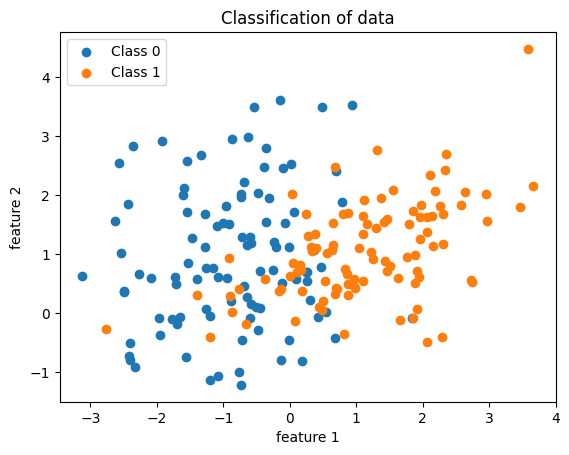

In [5]:
X, y = make_classification(n_samples=200, n_features=2, random_state=42, n_redundant=0, n_clusters_per_class=1)


plt.scatter(
    X[y == 0, 0],   # x values
    X[y == 0, 1],   # y values
    label='Class 0'
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label='Class 1'
)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Classification of data')
plt.legend()
plt.show()

In [6]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(sigmoid(0))
print(sigmoid(10))
print(sigmoid(-10))
print(sigmoid(7))

0.5
0.9999546021312976
4.5397868702434395e-05
0.9990889488055994


In [7]:
def log_loss(y, p, eps=1e-15):
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1 - y)* np.log(1 - p))

In [8]:

p = np.where(y == 1, 0.999, 0.001)
print(log_loss(y,p))

p = np.full_like(y, 0.5, dtype=float)
print(log_loss(y, p))

p = np.where(y == 1, 0.001, 0.999)
print(log_loss(y, p))

0.0010005003335835341
0.6931471805599452
6.907755278982137


What does eps guard against? What would happen without it?

eps is very tiny number in which helps in log_loss curve, because if we are not using eps, log(0) becomes negative infinity which breaks the logloss curve. so when we use eps the range will be very very tiny number in which it helps getting out of infinity values from log, so that log_loss curve will not be broken

In [ ]:
def compute_gradiants(X, y, w, b, epoch):

    z = X @ w + b

    p = sigmoid(z=z)

    if(epoch % 50 == 0):
        print(f'log-loss is {log_loss(p, y)}')
        
    dw = np.transpose(X) @ (p - y) / len(y)
    db = np.mean(p-y)

    return dw, db

In [ ]:
w_test = np.zeros(2)
b_test = 0.0 
dw, db = compute_gradiants(X, y, w_test, b_test)
print(dw.shape, dw, db)


In [21]:
w = np.zeros(2)
b = 0.0
lr=0.1
epochs = 1000
history = []

for epoch in range(epochs):
    dw, db = compute_gradiants(X, y, w, b)
    w = w - lr * dw
    b = b- lr * db

    if epoch % 50 == 0:
        z = X @ w + b
        p = sigmoid(z=z)

        lg_loss = log_loss(y, p)
        history.append(lg_loss)
        

print(w, b)

for value in history:
    print(value)


[ 1.94358239 -0.45303836] 0.21262408064731206
0.6688770138811501
0.4035956866815645
0.3788988210474004
0.37175806966602437
0.3689106900421157
0.36757522098648754
0.36688330076416326
0.36650015154889465
0.366277956395932
0.36614483496578853
0.3660632133833735
0.36601233732721916
0.365980250628069
0.36595984322383657
0.3659467853749297
0.3659383937667796
0.3659329838844656
0.3659294882360019
0.365927225684594
0.3659257594350207


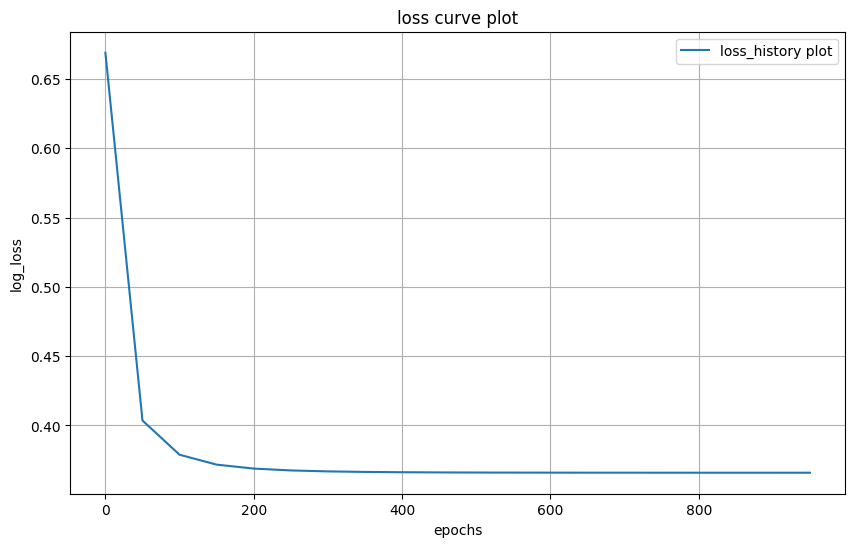

In [29]:
epoch_history_indices = range(0, epochs, 50)
plt.figure(figsize=(10, 6))
plt.plot(epoch_history_indices, history, label='loss_history plot')
plt.title('loss curve plot')
plt.xlabel('epochs')
plt.ylabel('log_loss')
plt.grid()
plt.legend()
plt.show()

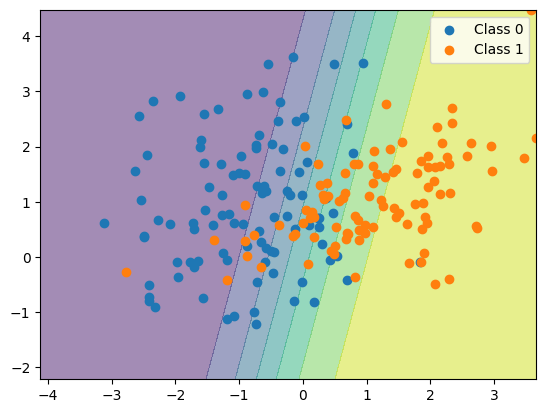

In [35]:
x1_range = np.linspace(X[:,0].min() - 1, X[:, 0].max(), 200)
x2_range = np.linspace(X[:, 1].min() -1, X[:,1].max(), 200)

xx1, xx2 = np.meshgrid(x1_range, x2_range)

grid = np.c_[xx1.ravel(), xx2.ravel()]

z = grid @ w + b
preds = sigmoid(z)

Z = preds.reshape(xx1.shape)

# contour plot
plt.contourf(xx1, xx2, Z, alpha=0.5)

# scatter points
plt.scatter(X[y == 0, 0],
            X[y == 0, 1],
            label='Class 0')

plt.scatter(X[y == 1, 0],
            X[y == 1, 1],
            label='Class 1')

plt.legend()
plt.show()
